In [1]:
import pandas as pd
df = pd.read_csv('c:/data/rides/rides2.csv')
df

,weekend,num.child,distance,rides,games,wait,clean,overall
0,1,0,114.648259,87,73,60,89,0
1,1,2,27.014097,87,78,76,87,1
2,0,1,63.300975,85,80,70,88,1
3,1,0,25.909931,88,72,66,89,0
4,0,4,54.718307,84,87,74,87,1
...,...,...,...,...,...,...,...,...
495,0,0,11.052577,90,72,68,90,0
496,1,0,8.187740,91,83,82,91,0
497,0,2,45.177402,95,92,85,93,1
498,0,3,27.088380,83,83,80,88,1


In [2]:
df['overall'].value_counts()

overall
1    255
0    245
Name: count, dtype: int64

In [3]:
train_cols = df.columns[:-1]
X = df[train_cols]
y = df['overall']

In [4]:
# 언더샘플링
from imblearn.under_sampling import RandomUnderSampler
X_sample, y_sample = RandomUnderSampler(random_state=0).fit_resample(X,y)
X_samp = pd.DataFrame(data=X_sample, columns=train_cols)
y_samp = pd.DataFrame(data=y_sample, columns=['overall'])
df2 = pd. concat([X_samp, y_samp], axis=1)
df2['overall'].value_counts()

overall
0    245
1    245
Name: count, dtype: int64

In [5]:
X = X_samp[train_cols]
y = y_samp['overall']

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=10)

In [9]:
from sklearn.tree import DecisionTreeClassifier
model1 =  DecisionTreeClassifier(max_depth=3, random_state=0)
model1.fit(X_train, y_train)
print('학습용:', model1.score(X_train, y_train))
print('검증용:', model1.score(X_test, y_test))

학습용: 0.8494897959183674
검증용: 0.7857142857142857


In [17]:
X.shape

(490, 7)

In [13]:
# 변수별 특성중요도(모형 만드는 데 기여도)
model1.feature_importances_

array([0.        , 0.34118635, 0.        , 0.02983217, 0.        ,
       0.20533133, 0.42365015])

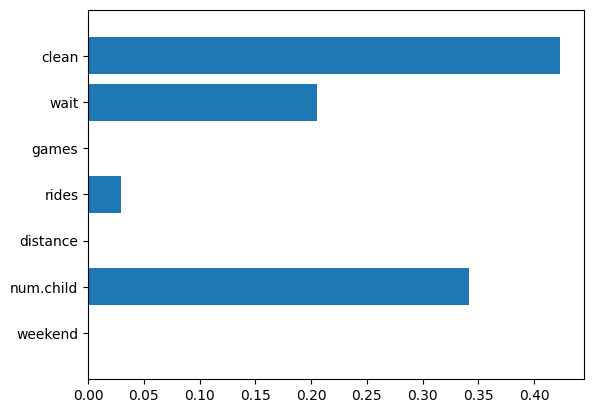

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def plot_tree(model):
    n_features = X.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), train_cols)
    plt.ylim(-1,n_features)

plot_tree(model1)